In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.cm as cm
from box_embeddings.parameterizations import MinDeltaBoxTensor
from box_embeddings.modules.intersection import GumbelIntersection
from box_embeddings.modules.volume import SoftVolume

# --- 1. SETUP ---
k = 5
num_dims = 2
feature_dim = 64
batch_size = 4

torch.manual_seed(42)
features = torch.randn(batch_size, feature_dim)

# Layer 1: Dalle Feature ai Box (4 coordinate)
projectors = nn.ModuleList([
    nn.Linear(in_features=feature_dim, out_features=2 * num_dims) for _ in range(k)
])

# Layer 2: Dai Box (4 coordinate) alla Probabilità (1 logit)
# QUESTO È IL PASSAGGIO CHIAVE! Dipende unicamente dalla geometria.
prob_predictors = nn.ModuleList([
    nn.Linear(in_features=2 * num_dims, out_features=1) for _ in range(k)
])

# Passiamo all'ottimizzatore i parametri di ENTRAMBI i gruppi di layer
optimizer = torch.optim.Adam(
    list(projectors.parameters()) + list(prob_predictors.parameters()), 
    lr=0.01
)

gumbel_intersection = GumbelIntersection(intersection_temperature=0.1)
soft_volume = SoftVolume(volume_temperature=0.5)

# --- 2. GROUND TRUTH ---
supervisions = [
    (0, 1, 1.0), 
    (0, 2, 1.0), 
    (1, 2, 0.0), 
    (2, 1, 0.0),
    (1, 3, 1.0), 
    (1, 4, 1.0), 
    (3, 4, 0.0), 
    (4, 3, 0.0),
]

concept_labels = torch.tensor([
    [1.0, 1.0, 0.0, 1.0, 0.0],
    [1.0, 0.0, 1.0, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 0.0],
    [1.0, 1.0, 0.0, 0.0, 1.0],
], dtype=torch.float32)

AllenNLP not available. Registrable won't work.


In [2]:
epochs = 350 # Aumentiamo un po' le epoche data la maggiore complessità

for epoch in range(epochs):
    optimizer.zero_grad()
    
    boxes = []
    logits = []
    
    # --- FASE 1: Feature -> Box ---
    for i in range(k):
        theta_i = projectors[i](features) # (batch, 4)
        box_i = MinDeltaBoxTensor(theta_i.view(batch_size, 2, num_dims))
        boxes.append(box_i)
        
        # --- FASE 2: Box -> Probabilità ---
        # Estraiamo le coordinate reali z e Z che formano il box
        # Flattenizziamo le coordinate per darle in pasto al Linear (batch, 4)
        box_coords = torch.cat([box_i.z, box_i.Z], dim=-1) 
        
        # Il layer calcola la probabilità guardando SOLO la geometria del box
        logit_i = prob_predictors[i](box_coords).squeeze(-1) # (batch,)
        logits.append(logit_i)
        
    # --- CALCOLO DELLE LOSS ---
    
    # Loss 1: Attivazione dei Concetti (Basata sulla geometria)
    logits_tensor = torch.stack(logits, dim=1) # (batch, k)
    concept_probs = torch.sigmoid(logits_tensor)
    activation_loss = F.binary_cross_entropy(concept_probs, concept_labels)
    
    # Loss 2: Gerarchia (Intersezioni e Disgiunzioni)
    hierarchy_loss = 0.0
    for target_id, source_id, target_prob in supervisions:
        b_target = boxes[target_id]
        b_source = boxes[source_id]
        
        int_box = gumbel_intersection(b_target, b_source)
        log_vol_int = soft_volume(int_box)
        log_vol_source = soft_volume(b_source)
        
        pred_prob = torch.exp(log_vol_int - log_vol_source)
        pred_prob = torch.clamp(pred_prob, 1e-6, 1.0 - 1e-6)
        
        target_tensor = torch.full((batch_size,), target_prob, dtype=torch.float32)
        hierarchy_loss += F.binary_cross_entropy(pred_prob, target_tensor)
        
    # Loss 3: Anti-Collasso dei Volumi
    vol_loss = 0.0
    for i in range(1, k):
        vol_loss -= 0.1 * soft_volume(boxes[i]).mean()

    # Combinazione e Backpropagation
    final_loss = activation_loss + hierarchy_loss + vol_loss
    
    final_loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoca {epoch+1} | Act: {activation_loss.item():.3f} | Hier: {hierarchy_loss.item():.3f}")

# Valutazione finale
with torch.no_grad():
    print("\n--- Probabilità di Attivazione (Calcolate dai Box) vs Ground Truth ---")
    final_probs = []
    for i in range(k):
        # Ripetiamo la cascata
        theta = projectors[i](features).view(batch_size, 2, num_dims)
        box = MinDeltaBoxTensor(theta)
        coords = torch.cat([box.z, box.Z], dim=-1)
        prob = torch.sigmoid(prob_predictors[i](coords).squeeze(-1))
        final_probs.append(prob)
        
    final_probs_tensor = torch.stack(final_probs, dim=1)
    
    for b in range(batch_size):
        print(f"Immagine {b}:")
        print(f"  Previste: {final_probs_tensor[b].numpy().round(2)}")
        print(f"  Reali:    {concept_labels[b].numpy()}")

Epoca 50 | Act: 0.337 | Hier: 0.072
Epoca 100 | Act: 0.104 | Hier: 0.093
Epoca 150 | Act: 0.034 | Hier: 0.063
Epoca 200 | Act: 0.015 | Hier: 0.048
Epoca 250 | Act: 0.009 | Hier: 0.040
Epoca 300 | Act: 0.006 | Hier: 0.034
Epoca 350 | Act: 0.004 | Hier: 0.030

--- Probabilità di Attivazione (Calcolate dai Box) vs Ground Truth ---
Immagine 0:
  Previste: [1.   1.   0.   0.99 0.  ]
  Reali:    [1. 1. 0. 1. 0.]
Immagine 1:
  Previste: [1.   0.01 0.99 0.01 0.  ]
  Reali:    [1. 0. 1. 0. 0.]
Immagine 2:
  Previste: [0.01 0.   0.   0.   0.  ]
  Reali:    [0. 0. 0. 0. 0.]
Immagine 3:
  Previste: [0.99 1.   0.01 0.   1.  ]
  Reali:    [1. 1. 0. 0. 1.]


In [3]:
def plot_boxes_k(boxes_list, batch_idx, k_concepts, title):
    fig, ax = plt.subplots(figsize=(6, 6))
    
    # Generiamo dinamicamente k colori da una colormap
    colormap = cm.get_cmap('tab10', k_concepts)
    
    for i in range(k_concepts):
        # Estraiamo le coordinate per l'elemento del batch
        z_coords = boxes_list[i].z[batch_idx].detach().numpy()
        Z_coords = boxes_list[i].Z[batch_idx].detach().numpy()
        
        width = Z_coords[0] - z_coords[0]
        height = Z_coords[1] - z_coords[1]
        
        color = colormap(i)
        rect = patches.Rectangle((z_coords[0], z_coords[1]), width, height, 
                                 linewidth=2, edgecolor=color, facecolor=color, 
                                 alpha=0.3, label=f'Concept {i}')
        ax.add_patch(rect)
        
    ax.autoscale_view()
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.title(title)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


--- Probabilità di Attivazione (Calcolate dai Box) vs Ground Truth ---
Immagine 0:
  Previste: [1.   1.   0.   0.99 0.  ]
  Reali:    [1. 1. 0. 1. 0.]
Immagine 1:
  Previste: [1.   0.01 0.99 0.01 0.  ]
  Reali:    [1. 0. 1. 0. 0.]
Immagine 2:
  Previste: [0.01 0.   0.   0.   0.  ]
  Reali:    [0. 0. 0. 0. 0.]
Immagine 3:
  Previste: [0.99 1.   0.01 0.   1.  ]
  Reali:    [1. 1. 0. 0. 1.]


/var/folders/nd/ckd2p671409_45_1_kmhw0bh0000gn/T/ipykernel_2407/3022420234.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('tab10', k_concepts)


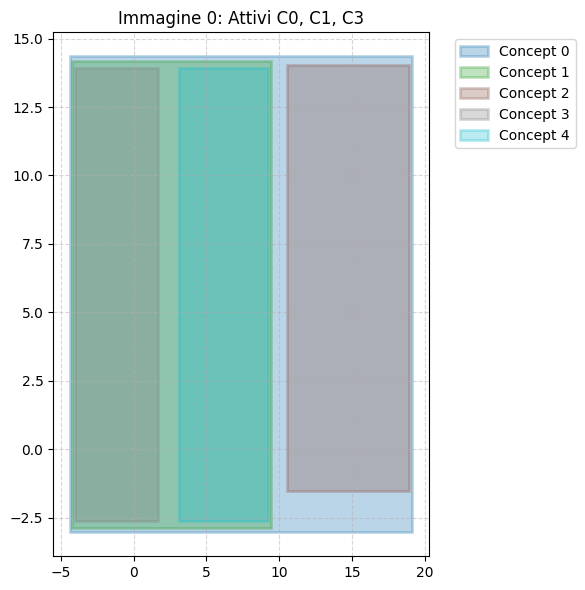

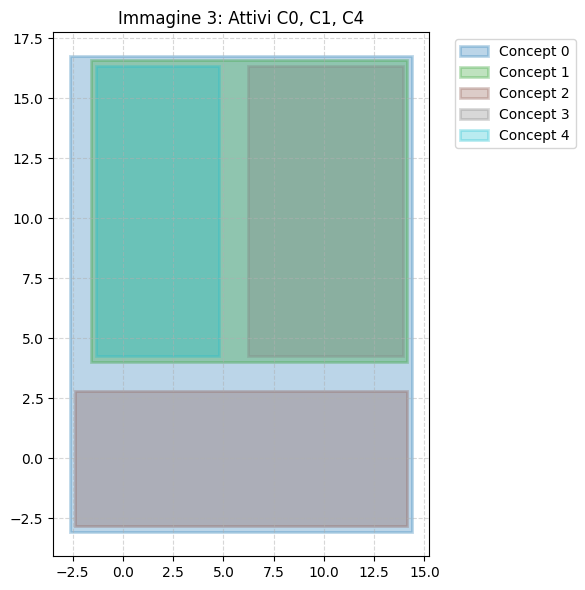

In [4]:
# Valutazione e VISUALIZZAZIONE finale
with torch.no_grad():
    print("\n--- Probabilità di Attivazione (Calcolate dai Box) vs Ground Truth ---")
    final_probs = []
    final_boxes = [] # Lista per salvare i box da plottare!
    
    for i in range(k):
        # Ripetiamo la cascata
        theta = projectors[i](features).view(batch_size, 2, num_dims)
        box = MinDeltaBoxTensor(theta)
        coords = torch.cat([box.z, box.Z], dim=-1)
        prob = torch.sigmoid(prob_predictors[i](coords).squeeze(-1))
        
        final_probs.append(prob)
        final_boxes.append(box) # Salviamo il box per il grafico
        
    final_probs_tensor = torch.stack(final_probs, dim=1)
    
    for b in range(batch_size):
        print(f"Immagine {b}:")
        print(f"  Previste: {final_probs_tensor[b].numpy().round(2)}")
        print(f"  Reali:    {concept_labels[b].numpy()}")

# Assicurati di avere la funzione plot_boxes_k definita più in alto nel notebook!
# Visualizziamo i box per due immagini con concetti attivi diversi
plot_boxes_k(final_boxes, batch_idx=0, k_concepts=k, title="Immagine 0: Attivi C0, C1, C3")
plot_boxes_k(final_boxes, batch_idx=3, k_concepts=k, title="Immagine 3: Attivi C0, C1, C4")


--- Probabilità di Attivazione (Calcolate dai Box) vs Ground Truth ---
Immagine 0:
  Previste: [1.   1.   0.   0.99 0.  ]
  Reali:    [1. 1. 0. 1. 0.]
Immagine 1:
  Previste: [1.   0.01 0.99 0.01 0.  ]
  Reali:    [1. 0. 1. 0. 0.]
Immagine 2:
  Previste: [0.01 0.   0.   0.   0.  ]
  Reali:    [0. 0. 0. 0. 0.]
Immagine 3:
  Previste: [0.99 1.   0.01 0.   1.  ]
  Reali:    [1. 1. 0. 0. 1.]


/var/folders/nd/ckd2p671409_45_1_kmhw0bh0000gn/T/ipykernel_2407/3022420234.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('tab10', k_concepts)


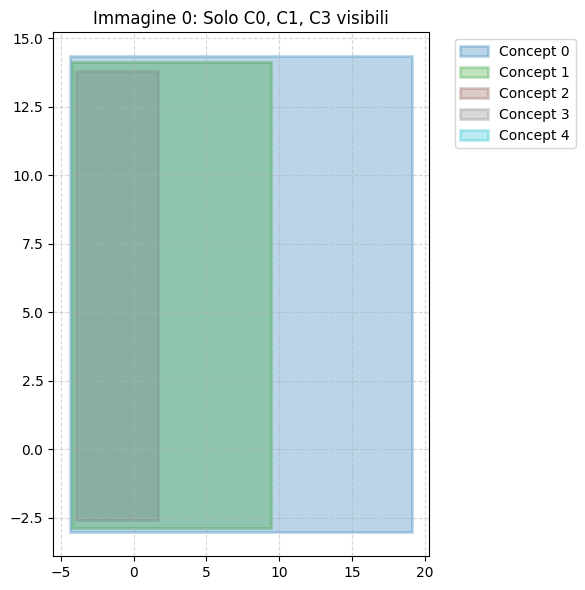

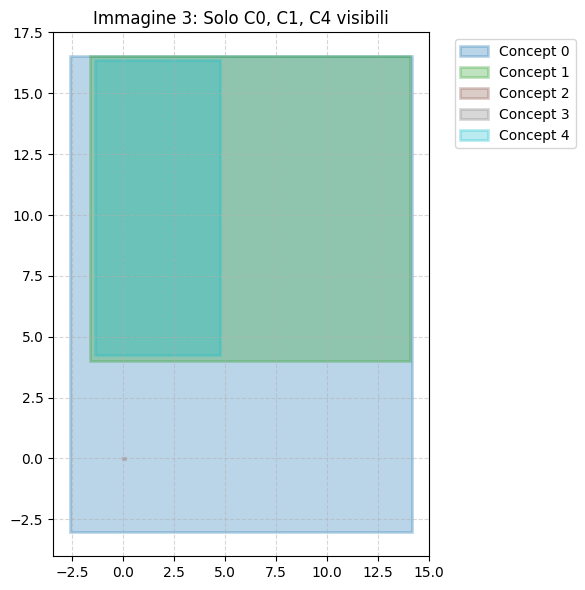

In [15]:
from box_embeddings.parameterizations import BoxTensor

# --- VALUTAZIONE E VISUALIZZAZIONE DEI BOX SCALATI ---
with torch.no_grad():
    print("\n--- Probabilità di Attivazione (Calcolate dai Box) vs Ground Truth ---")
    final_probs = []
    final_boxes = [] 
    scaled_boxes = [] # Nuova lista per i box moltiplicati per la probabilità!
    
    for i in range(k):
        # 1. Ricreiamo il box originale
        theta = projectors[i](features).view(batch_size, 2, num_dims)
        box = MinDeltaBoxTensor(theta)
        coords = torch.cat([box.z, box.Z], dim=-1)
        
        # 2. Calcoliamo la probabilità
        prob = torch.sigmoid(prob_predictors[i](coords).squeeze(-1))
        
        final_probs.append(prob)
        final_boxes.append(box)
        
        # 3. CREIAMO IL BOX SCALATO
        # Aggiungiamo una dimensione a prob (da [batch] a [batch, 1]) per poterla 
        # moltiplicare con le coordinate z e Z che hanno shape [batch, 2]
        prob_expanded = prob.unsqueeze(-1) 
        
        z_scaled = box.z * prob_expanded
        Z_scaled = box.Z * prob_expanded
        
        # Concateniamo z e Z scalati per creare un BoxTensor base
        theta_scaled = torch.stack([z_scaled, Z_scaled], dim=-2)
    
        scaled_box = BoxTensor(theta_scaled)
        scaled_boxes.append(scaled_box)
        
    final_probs_tensor = torch.stack(final_probs, dim=1)
    
    for b in range(batch_size):
        print(f"Immagine {b}:")
        print(f"  Previste: {final_probs_tensor[b].numpy().round(2)}")
        print(f"  Reali:    {concept_labels[b].numpy()}")

# Visualizziamo i BOX SCALATI! I concetti con probabilità ~0 scompariranno nell'origine.
plot_boxes_k(scaled_boxes, batch_idx=0, k_concepts=k, title="Immagine 0: Solo C0, C1, C3 visibili")
plot_boxes_k(scaled_boxes, batch_idx=3, k_concepts=k, title="Immagine 3: Solo C0, C1, C4 visibili")